In [1]:
import numpy as np
import pandas as pd

In [2]:
cols = ["target","id","date","flag","user","text"]
df=pd.read_csv("training.1600000.processed.noemoticon.csv",encoding='latin1',names=cols)

In [3]:
df

,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
...,...,...,...,...,...,...
1599995,4,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599996,4,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599997,4,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599998,4,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...


In [4]:
df.columns

Index(['target', 'id', 'date', 'flag', 'user', 'text'], dtype='object')

In [5]:
# here i want only the target column and the text column

In [6]:
dff=df[["target","text"]].copy()

In [7]:
dff

,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."
...,...,...
1599995,4,Just woke up. Having no school is the best fee...
1599996,4,TheWDB.com - Very cool to hear old Walt interv...
1599997,4,Are you ready for your MoJo Makeover? Ask me f...
1599998,4,Happy 38th Birthday to my boo of alll time!!! ...


In [8]:
dff["target"].value_counts()

target
0    800000
4    800000
Name: count, dtype: int64

In [9]:
dff["target"]=dff["target"].map({0:"Negative",4:"Positive"})
dff.head(3)

,target,text
0,Negative,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,Negative,is upset that he can't update his Facebook by ...
2,Negative,@Kenichan I dived many times for the ball. Man...


In [10]:
dff.shape

(1600000, 2)

In [11]:
dff.isnull().sum()

target    0
text      0
dtype: int64

In [12]:
dff.duplicated().sum()

16309

In [13]:
dff.drop_duplicates()

,target,text
0,Negative,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,Negative,is upset that he can't update his Facebook by ...
2,Negative,@Kenichan I dived many times for the ball. Man...
3,Negative,my whole body feels itchy and like its on fire
4,Negative,"@nationwideclass no, it's not behaving at all...."
...,...,...
1599995,Positive,Just woke up. Having no school is the best fee...
1599996,Positive,TheWDB.com - Very cool to hear old Walt interv...
1599997,Positive,Are you ready for your MoJo Makeover? Ask me f...
1599998,Positive,Happy 38th Birthday to my boo of alll time!!! ...


In [14]:
def length(text):
    return len(str(text).split())

In [15]:
dff["length"]=dff["text"].apply(length)

In [16]:
dff.head(3)

,target,text,length
0,Negative,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",19
1,Negative,is upset that he can't update his Facebook by ...,21
2,Negative,@Kenichan I dived many times for the ball. Man...,18


In [17]:
dff["length"].describe()

count    1.600000e+06
mean     1.317615e+01
std      6.957978e+00
min      1.000000e+00
25%      7.000000e+00
50%      1.200000e+01
75%      1.900000e+01
max      6.400000e+01
Name: length, dtype: float64

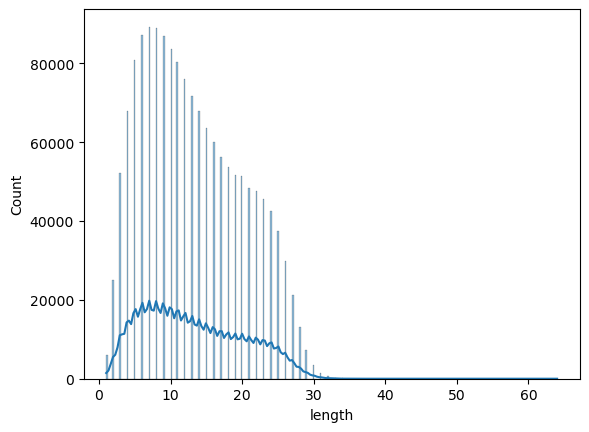

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(dff["length"],kde=True)
plt.show()

In [19]:
#here we sees that there is some text are longer then 80000 counts
#most tweets are short
#and also the length make the model baised sometimes 

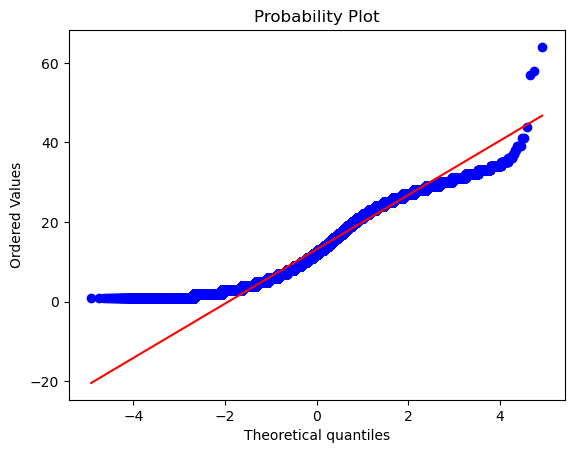

In [20]:
from scipy import stats
stats.probplot(dff["length"],dist="norm",plot=plt)
plt.show()

In [21]:
# H0:data follows the normal distribution
# H1:data not follows the normal distribution
from scipy.stats import kstest
z_score=(dff["length"]-dff["length"].mean())/dff["length"].std()
test_ststistics,pvalue=kstest(z_score,"norm")
(test_ststistics,pvalue)
print(test_ststistics,pvalue)
alpha=0.05
if pvalue < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

0.09340616252898865 0.0
Reject H0


In [22]:
# here we have a strong evidence that alpha is greater then the pvalue so we conclude taht data is not normally distributed 

In [23]:
stats.kurtosis(dff["length"])

-0.8450413144443898

In [24]:
# here we sees that we have negative kurtosis which means we have a fewer extreme outlier

In [25]:
stats.skew(dff["length"])

0.3772273763510232

In [26]:
# here we sees that our data is right skewed

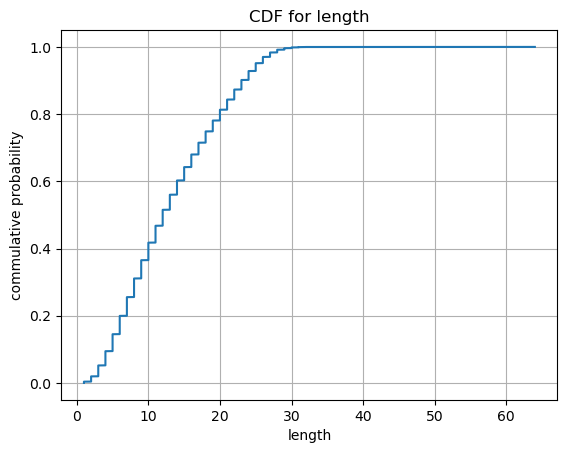

In [27]:
sorted_data=np.sort(dff["length"])
cdf_values=np.arange(1,len(sorted_data)+1)/len(sorted_data)
plt.title("CDF for length")
plt.xlabel("length")
plt.ylabel("commulative probability")
plt.plot(sorted_data,cdf_values)
plt.grid()
plt.show()

In [28]:
# here we sees that the 97% text has lenth less then 30

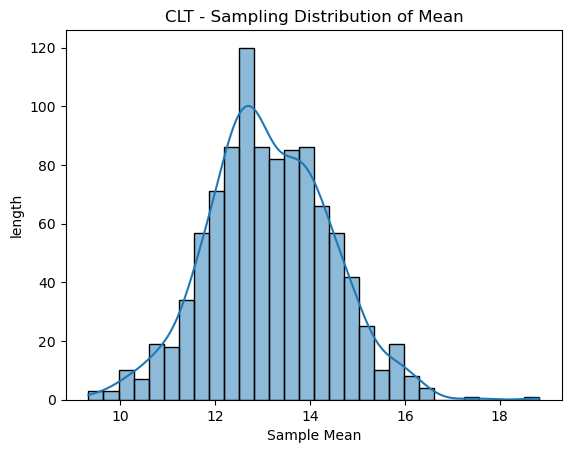

In [29]:
data=dff["length"]
sample_size=30
num_samples=1000
sample_means=[]
for i in range(num_samples):
    sample=np.random.choice(data,sample_size,replace=True)
    sample_means.append(np.mean(sample))
sample_means=np.array(sample_means)
sns.histplot(sample_means,bins=30,kde=True)
plt.title("CLT - Sampling Distribution of Mean")
plt.xlabel("Sample Mean")
plt.ylabel("length")
plt.show()

In [30]:
# after applying CLT we sees that the data is looking some what gaussian

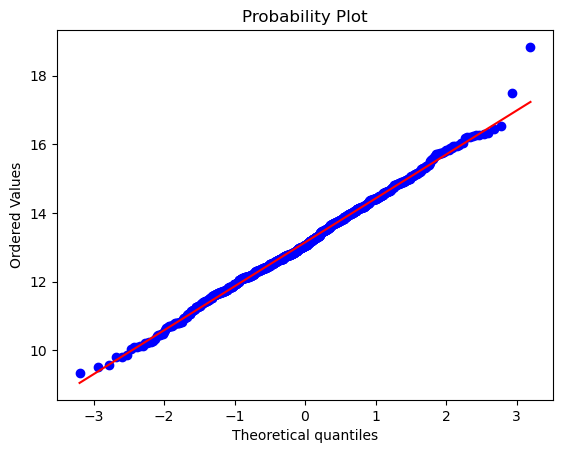

In [31]:
stats.probplot(sample_means,dist="norm",plot=plt)
plt.show()

In [32]:
# after applying CLT wee sees that the data is looking some what gaussian but not 
# a perfectly gaussian distribution

In [33]:
from collections import Counter
all_words=" ".join(dff["text"]).split()
Counter(all_words).most_common(30)

[('to', 552962),
 ('I', 496619),
 ('the', 487501),
 ('a', 366212),
 ('my', 280025),
 ('and', 275263),
 ('i', 250016),
 ('is', 217693),
 ('you', 213871),
 ('for', 209801),
 ('in', 202294),
 ('of', 179554),
 ('it', 171812),
 ('on', 154365),
 ('have', 132249),
 ('so', 125155),
 ('me', 122509),
 ('that', 118685),
 ('with', 110843),
 ('be', 108069),
 ('but', 106272),
 ('at', 102196),
 ("I'm", 99559),
 ('was', 99140),
 ('just', 96284),
 ('not', 88110),
 ('this', 77810),
 ('get', 76734),
 ('like', 73302),
 ('are', 72568)]

In [34]:
#here we sees the text has so many stopword so we have to do the stopword removal

In [35]:
dff.duplicated().sum()

16309

In [36]:
dff=dff.drop_duplicates()

In [37]:
# here we sees the dataset is too big so we have to  make the subset

In [38]:
dff.shape

(1583691, 3)

In [39]:
# if we are going for aprroximatly 1.6 millian datapoint it will take more time and so we take 100000 sample from dataset which make our training in less time 

In [40]:
dff=dff.sample(100000,random_state=42)

In [41]:
#now we have to balance the datset with equal positive and negative 

In [42]:
min_count=dff['target'].value_counts().min()
dff=(dff.groupby("target").sample(n=min_count,random_state=42).reset_index(drop=True))

In [43]:
dff["target"].value_counts()

target
Negative    49898
Positive    49898
Name: count, dtype: int64

In [44]:
dff.head(5)

,target,text,length
0,Negative,@emilyjester i hate that tooo!!!!,5
1,Negative,Thanks. Upsetting doing the form but expected,7
2,Negative,bout to go to sleep...missin the Boo,7
3,Negative,@buddhawong you just found ooooout ? imy by t...,12
4,Negative,Tootie turned 5 today!!! Where does the time ...,9


In [45]:
dff=dff.drop(columns=["length"])

In [46]:
dff.head(3)

,target,text
0,Negative,@emilyjester i hate that tooo!!!!
1,Negative,Thanks. Upsetting doing the form but expected
2,Negative,bout to go to sleep...missin the Boo


In [47]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
stop_words=set(stopwords.words("english"))
lemmatizer=WordNetLemmatizer()
def clean_text(text):
    text=str(text).lower()
    text=re.sub(r"https?://\S+|www\.\S+","",text)
    text=re.sub(r"\d+","",text)
    text=re.sub(f"[{re.escape(string.punctuation)}]","",text)
    text=re.sub(r"(.)\1+",r"\1\1",text)
    text=re.sub(r"\s+"," ",text).strip()
    words=text.split()
    cleaned_words=[]
    for w in words:
        if w not in stop_words:
            w=lemmatizer.lemmatize(w)
            cleaned_words.append(w)
    return " ".join(cleaned_words)

In [48]:
dff["text"]=dff["text"].apply(clean_text)

In [49]:
dff.head(3)

,target,text
0,Negative,emilyjester hate
1,Negative,thanks upsetting form expected
2,Negative,bout go sleepmissin boo


In [50]:
from sklearn.model_selection import train_test_split

In [51]:
x=dff["text"]
y=dff["target"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=5000)
x_train_tfidf=tfidf.fit_transform(x_train)
x_test_tfidf=tfidf.transform(x_test)

In [53]:
from sklearn.naive_bayes import MultinomialNB
nbmodel=MultinomialNB()
nbmodel.fit(x_train_tfidf,y_train)

MultinomialNB()

In [54]:
nbpred=nbmodel.predict(x_test_tfidf)

In [55]:
from sklearn.metrics import accuracy_score,classification_report
print(accuracy_score(y_test,nbpred))
print(classification_report(y_test,nbpred))

0.75
              precision    recall  f1-score   support

    Negative       0.76      0.74      0.75     10064
    Positive       0.74      0.76      0.75      9896

    accuracy                           0.75     19960
   macro avg       0.75      0.75      0.75     19960
weighted avg       0.75      0.75      0.75     19960



In [56]:
from sklearn.linear_model import LogisticRegression
model1=LogisticRegression(max_iter=1000)
model1.fit(x_train_tfidf,y_train)

LogisticRegression(max_iter=1000)

In [57]:
y_pred=model1.predict(x_test_tfidf)

In [58]:
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.762625250501002
              precision    recall  f1-score   support

    Negative       0.78      0.74      0.76     10064
    Positive       0.75      0.79      0.77      9896

    accuracy                           0.76     19960
   macro avg       0.76      0.76      0.76     19960
weighted avg       0.76      0.76      0.76     19960



In [59]:
# we have maked the model so we have to test

In [60]:
def predict_sentiment(text):
    text = clean_text(text)
    vector = tfidf.transform([text])
    pred = model1.predict(vector)[0]
    prob = model1.predict_proba(vector).max()
    
    return pred, prob

In [61]:
predict_sentiment("i am to much tired and dilevery did not come on time")

('Negative', 0.7409574538267786)

In [62]:
# TF-IDF was used to convert text into numerical features, and Logistic Regression was applied for classification due to its efficiency and strong performance on text data.

In [63]:
predict_sentiment("Uber ride was very smooth and driver was polite")

('Positive', 0.7430341716189438)

In [64]:
predict_sentiment("Swiggy delivery was very late and food was cold")

('Negative', 0.8461639970836388)

In [65]:
predict_sentiment("Amazon product quality is amazing")

('Positive', 0.8448922442030936)

In [66]:
print("Logistic Regression:",accuracy_score(y_test,y_pred))
print("Naive Bayes:",accuracy_score(y_test,nbpred))

Logistic Regression: 0.762625250501002
Naive Bayes: 0.75


In [67]:
import pickle
pickle.dump(model1,open("model.pkl", "wb"))
pickle.dump(tfidf,open("tfidf.pkl", "wb"))

In [ ]:
!streamlit run reviewanalysis.py